# Optimized Deep Learning Image Classification on Oxford-IIIT Pet Dataset

This notebook provides a modular and lightweight solution for image classification using a subset of the Oxford-IIIT Pet Dataset. It's designed for fast experimentation on Google Colab's free GPU resources, focusing on efficient data pipelines and optimized training runs.

---

## SECTION 1 — MODEL

### A. Environment Setup

This section sets up the Google Colab environment, including TensorFlow, GPU detection, Google Drive mounting for persistent storage, and creation of necessary directories.

In [ ]:
# Import necessary libraries
import tensorflow as tf
import os
import datetime
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


#### GPU Detection

In [ ]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
        print("GPU is available and configured.")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU devices found. Training will run on CPU.")

1 Physical GPUs, 1 Logical GPUs
GPU is available and configured.


#### Mount Google Drive

In [ ]:
# Mount Google Drive to save models and results
drive.mount('/content/drive')

# Define base path for saving outputs
BASE_PATH = '/content/drive/MyDrive/Colab_DL_Project'

# Create base directory if it doesn't exist
if not os.path.exists(BASE_PATH):
    os.makedirs(BASE_PATH)
    print(f"Created base directory: {BASE_PATH}")
else:
    print(f"Base directory already exists: {BASE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base directory already exists: /content/drive/MyDrive/Colab_DL_Project


#### Checkpoint and Experiment Directories

In [ ]:
# Define specific directories for checkpoints and experiment results
CHECKPOINT_DIR = os.path.join(BASE_PATH, 'checkpoints')
EXPERIMENT_RESULTS_DIR = os.path.join(BASE_PATH, 'experiment_results')

# Create directories if they don't exist
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(EXPERIMENT_RESULTS_DIR, exist_ok=True)

print(f"Checkpoint directory: {CHECKPOINT_DIR}")
print(f"Experiment results directory: {EXPERIMENT_RESULTS_DIR}")

Checkpoint directory: /content/drive/MyDrive/Colab_DL_Project/checkpoints
Experiment results directory: /content/drive/MyDrive/Colab_DL_Project/experiment_results


### B. Dataset Preparation

This section handles the download and initial processing of the Oxford-IIIT Pet Dataset. We will use `tensorflow_datasets` to efficiently load the data. To meet the optimization requirements for fast experimentation, we will focus on:

*   **Sampling a small subset** of images per class.
*   **Resizing images** to a smaller `128x128` resolution.
*   Creating **train, validation, and test splits**.

In [ ]:
# Install tensorflow_datasets if not already installed
try:
    import tensorflow_datasets as tfds
    print("tensorflow_datasets already installed.")
except ImportError:
    print("Installing tensorflow_datasets...")
    !pip install tensorflow_datasets
    import tensorflow_datasets as tfds
    print("tensorflow_datasets installed.")

tensorflow_datasets already installed.


#### Download and Load Dataset

In [ ]:
DATASET_NAME = 'oxford_iiit_pet'
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32 # or 16

# New Sampling Strategy: 500 images across 5 classes (100 images per class)
NUM_CLASSES_TO_SAMPLE = 5
MAX_IMAGES_PER_CHOSEN_CLASS = 100

# Get dataset info
builder = tfds.builder(DATASET_NAME)
info = builder.info
FULL_NUM_CLASSES = info.features['label'].num_classes # Total available classes
print(f"Dataset: {DATASET_NAME}")
print(f"Total available classes: {FULL_NUM_CLASSES}")

# Explicitly download and prepare the dataset to ensure it's ready
print("Downloading and preparing dataset...")
builder.download_and_prepare()
print("Dataset prepared.")

# Load the dataset for sampling
# as_supervised=False to access all features for sampling
print("Loading full dataset splits for sampling...")
dataset = tfds.load(DATASET_NAME, as_supervised=False)
print("Full dataset splits loaded.")

def sample_specific_classes_dataset(
    dataset_split,
    num_classes_to_sample,
    max_images_per_chosen_class,
    full_num_classes,
    seed=42
):
    print("Starting dataset sampling with specific class selection...")
    np.random.seed(seed)

    # Randomly select N classes
    selected_class_ids = np.random.choice(
        full_num_classes, num_classes_to_sample, replace=False
    )
    print(f"Randomly selected classes: {selected_class_ids}")

    all_preprocessed_images = []  # Will store resized and normalized images
    all_labels = []

    print(f"Iterating through dataset_split (train part) to collect, resize, and normalize images for sampling...")
    item_count = 0
    for i, item in enumerate(tfds.as_numpy(dataset_split['train'])):
        # Only process images from selected classes
        if item['label'] in selected_class_ids:
            # Apply preprocessing (resize and normalize) here to ensure uniform shapes
            image = tf.image.resize(item['image'], IMAGE_SIZE)
            image = tf.cast(image, tf.float32) / 255.0  # Normalize to [0,1]
            all_preprocessed_images.append(image.numpy())  # Convert to numpy for list storage
            all_labels.append(item['label'])
            item_count += 1
            if item_count % 1000 == 0:  # Print progress every 1000 images
                print(f"  Collected and preprocessed {item_count} images...")

    print(f"Finished collecting and preprocessing {len(all_preprocessed_images)} images from selected classes.")

    indices_per_class = {class_id: [] for class_id in selected_class_ids}
    for i, label in enumerate(all_labels):
        indices_per_class[label].append(i)

    selected_indices = []
    for class_id in selected_class_ids:
        class_indices = indices_per_class[class_id]
        np.random.shuffle(class_indices)
        selected_indices.extend(class_indices[:max_images_per_chosen_class])

    np.random.shuffle(selected_indices)
    sampled_images = np.array(all_preprocessed_images)[selected_indices]  # This will now work correctly
    sampled_labels = np.array(all_labels)[selected_indices]

    print(f"Sampled {len(sampled_images)} images (max {max_images_per_chosen_class} per chosen class).")
    sampled_ds = tf.data.Dataset.from_tensor_slices((sampled_images, sampled_labels))
    print(f"Sampled dataset created with element_spec: {sampled_ds.element_spec}")
    return sampled_ds

# Sample the training split (and then split further)
sampled_full_dataset = sample_specific_classes_dataset(
    dataset,
    NUM_CLASSES_TO_SAMPLE,
    MAX_IMAGES_PER_CHOSEN_CLASS,
    FULL_NUM_CLASSES
)
NUM_CLASSES = NUM_CLASSES_TO_SAMPLE # Update NUM_CLASSES to reflect sampled classes
print(f"sampled_full_dataset successfully created. Cardinality: {tf.data.experimental.cardinality(sampled_full_dataset).numpy()}")

Dataset: oxford_iiit_pet
Total available classes: 37
Dataset prepared.
Loading full dataset splits for sampling...
Full dataset splits loaded.
Starting dataset sampling with specific class selection...
Randomly selected classes: [17 13  4 29 35]
Iterating through dataset_split (train part) to collect, resize, and normalize images for sampling...
Finished collecting and preprocessing 500 images from selected classes.
Sampled 500 images (max 100 per chosen class).
Sampled dataset created with element_spec: (TensorSpec(shape=(128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))
sampled_full_dataset successfully created. Cardinality: 500


#### Create Train, Validation, Test Splits

In [ ]:
# Apply preprocessing and then split
# Using a small percentage for test and validation from the sampled dataset
TOTAL_SAMPLED_IMAGES = tf.data.experimental.cardinality(sampled_full_dataset).numpy()
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

train_size = int(TRAIN_RATIO * TOTAL_SAMPLED_IMAGES)
val_size = int(VAL_RATIO * TOTAL_SAMPLED_IMAGES)

print(f"Total sampled images: {TOTAL_SAMPLED_IMAGES}")
print(f"Train size: {train_size}")
print(f"Validation size: {val_size}")
print(f"Test size: {TOTAL_SAMPLED_IMAGES - train_size - val_size}")

shuffled_sampled_dataset = sampled_full_dataset.shuffle(TOTAL_SAMPLED_IMAGES, seed=42)

# The images are already preprocessed (resized and normalized) during sampling,
# so we no longer need to map load_and_preprocess_image here.
train_ds = shuffled_sampled_dataset.take(train_size)
val_ds = shuffled_sampled_dataset.skip(train_size).take(val_size)
test_ds = shuffled_sampled_dataset.skip(train_size + val_size)

print(f"Train dataset size: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Validation dataset size: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Test dataset size: {tf.data.experimental.cardinality(test_ds).numpy()}")

Total sampled images: 500
Train size: 400
Validation size: 50
Test size: 50
Train dataset size: 400
Validation dataset size: 50
Test dataset size: 50


#### Display Sample Images

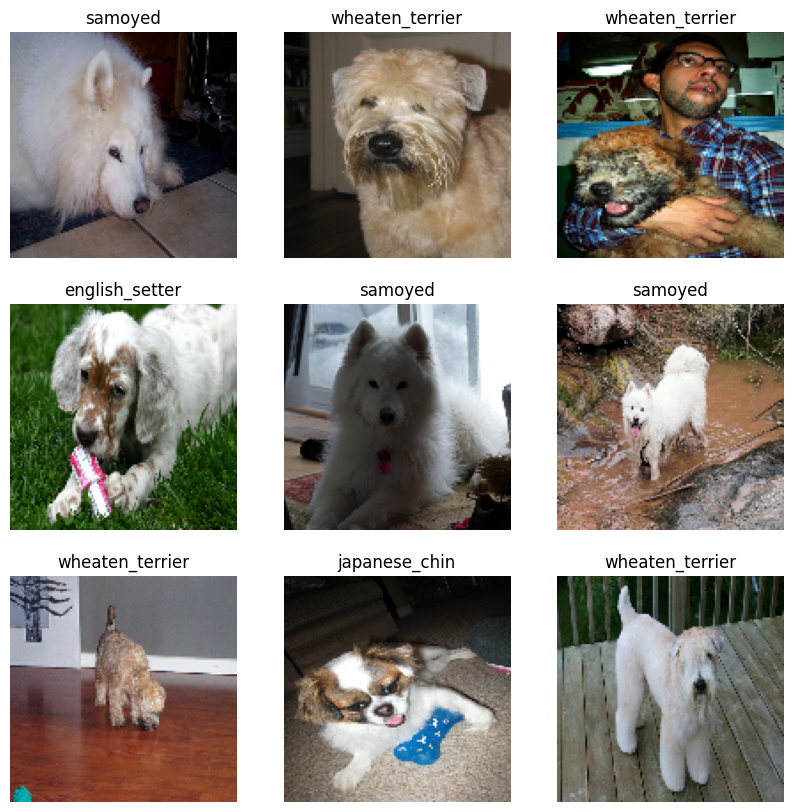

In [ ]:
def get_label_name(label):
    return info.features['label'].int2str(label)

plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(train_ds.take(9)):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image.numpy())
    plt.title(get_label_name(label.numpy()))
    plt.axis("off")
plt.show()

### C. Data Pipeline

This section constructs an optimized `tf.data` pipeline for training, validation, and testing. Key optimizations include:

*   **Normalization:** Scaling pixel values to a `[0, 1]` range (already done in `load_and_preprocess_image`).
*   **Data Augmentation:** Applying random transformations to the training data to improve model generalization.
*   **Caching:** Storing processed data in memory or disk to avoid reprocessing elements on each epoch.
*   **Prefetching:** Overlapping data preprocessing and model execution to keep the GPU busy.

#### Data Augmentation Layer (Optional)

In [ ]:
# Define data augmentation layers
def augment_data(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    # Add more augmentation as needed, e.g., random zoom, rotation
    return image, label

# Create a simple augmentation pipeline for CNN+Augmentation experiment
# This will be applied conditionally later
augmentation_pipeline = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.2)
], name="augmentation_pipeline")

def augment_fn(image, label):
    return augmentation_pipeline(image, training=True), label

#### Build the `tf.data` Pipeline

In [ ]:
def prepare_dataset(ds, shuffle=False, augment=False, cache=True):
    if cache:
        if isinstance(cache, str):
            ds = ds.cache(cache)
        else:
            ds = ds.cache()

    if shuffle:
        ds = ds.shuffle(buffer_size=1000) # Buffer size for shuffling

    # Apply augmentation only for training dataset and if specified
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    return ds

# Prepare the datasets
train_ds_prepared = prepare_dataset(train_ds, shuffle=True, augment=False) # For DNN/CNN without augmentation
train_ds_augmented_prepared = prepare_dataset(train_ds, shuffle=True, augment=True) # For CNN with augmentation
val_ds_prepared = prepare_dataset(val_ds, shuffle=False, augment=False)
test_ds_prepared = prepare_dataset(test_ds, shuffle=False, augment=False)

print("Data pipelines prepared with caching and prefetching.")

Data pipelines prepared with caching and prefetching.


### D. Model Architectures

This section defines the different model architectures required for the experiments. We will implement:

1.  **Simple DNN (Deep Neural Network):** A basic fully connected network.
2.  **Simple CNN (Convolutional Neural Network):** A small CNN with a few convolutional and pooling layers.
3.  **CNN with augmentation:** The same Simple CNN, but trained with data augmentation applied to the input pipeline.
4.  **Transfer Learning (MobileNetV2):** Utilizing a pre-trained MobileNetV2 model with a custom classification head.
5.  **Transfer Learning (ResNet50):** Utilizing a pre-trained ResNet50 model with a custom classification head.

All models are designed to be lightweight and suitable for fast experimentation with reduced image sizes and limited epochs.

#### Helper Function to Build Classification Head

In [ ]:
def build_classifier_head(num_classes, name=None):
    return tf.keras.Sequential([
        tf.keras.layers.GlobalAveragePooling2D() if name and 'CNN' in name else tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation='softmax', name='output_layer') # Fixed typo here
    ], name=name)

#### 1. Simple DNN

In [ ]:
def build_simple_dnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=input_shape),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ], name='SimpleDNN')
    return model

# Example usage (input_shape will be IMAGE_SIZE + (3,) )
# dnn_model = build_simple_dnn(IMAGE_SIZE + (3,), NUM_CLASSES)
# dnn_model.summary()

#### 2. Simple CNN

In [ ]:
def build_simple_cnn(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.Input(shape=input_shape), # Recommended way to define input shape
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ], name='SimpleCNN')
    return model

# Example usage
# cnn_model = build_simple_cnn(IMAGE_SIZE + (3,), NUM_CLASSES)
# cnn_model.summary()

#### 3. Transfer Learning: MobileNetV2

In [ ]:
def build_mobilenetv2(input_shape, num_classes):
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False, # Do not include the ImageNet classifier at the top
        weights='imagenet' # Load weights pre-trained on ImageNet
    )
    base_model.trainable = False # Freeze the base model for feature extraction

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False) # Important: set training=False to keep batchnorm layers in inference mode
    outputs = build_classifier_head(num_classes, name='MobileNetV2_Classifier')(x)
    model = tf.keras.Model(inputs, outputs, name='MobileNetV2_TL')

    return model

# Example usage
# mobilenet_model = build_mobilenetv2(IMAGE_SIZE + (3,), NUM_CLASSES)
# mobilenet_model.summary()

#### 4. Transfer Learning: ResNet50

In [ ]:
def build_resnet50(input_shape, num_classes):
    base_model = tf.keras.applications.ResNet50(
        input_shape=input_shape,
        include_top=False, # Do not include the ImageNet classifier at the top
        weights='imagenet' # Load weights pre-trained on ImageNet
    )
    base_model.trainable = False # Freeze the base model for feature extraction

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False) # Important: set training=False to keep batchnorm layers in inference mode
    outputs = build_classifier_head(num_classes, name='ResNet50_Classifier')(x)
    model = tf.keras.Model(inputs, outputs, name='ResNet50_TL')

    return model

# Example usage
# resnet_model = build_resnet50(IMAGE_SIZE + (3,), NUM_CLASSES)
# resnet_model.summary()

### E. Metrics

This section defines a comprehensive set of evaluation metrics to assess the performance of our classification models. Beyond standard accuracy, we will track:

*   **Accuracy**
*   **Precision**
*   **Recall (Sensitivity)**
*   **F1-score**
*   **True Positive Rate (TPR)**
*   **False Positive Rate (FPR)**
*   **True Negative Rate (TNR) (Specificity)**
*   **False Negative Rate (FNR)**
*   **Specificity**
*   **Sensitivity**

These metrics provide a more nuanced understanding of model behavior, especially in multi-class classification.

In [ ]:
from tensorflow.keras import metrics

def get_metrics(num_classes):
    METRICS = [
        # Temporarily using only 'loss' to bypass 'InvalidArgumentError' during XLA compilation
        # Detailed metrics will be calculated post-training using sklearn as per plan.
        # metrics.SparseCategoricalAccuracy(name='accuracy'), # This was causing a low-level graph error
    ]

    print("Standard Keras metrics initialized: [loss] for stable training.")
    print("Detailed per-class metrics (F1, Sensitivity, Specificity, TPR, FPR, TNR, FNR) will be calculated post-training from predictions.")

    return METRICS

#### Custom Metrics Calculation (Post-Training)

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

def calculate_detailed_metrics(y_true, y_pred, num_classes):
    y_true_labels = np.argmax(y_true, axis=1)
    y_pred_labels = np.argmax(y_pred, axis=1)

    # Compute global metrics
    accuracy = metrics.Accuracy()(y_true_labels, y_pred_labels).numpy()
    precision_macro = precision_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
    recall_macro = recall_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)
    f1_macro = f1_score(y_true_labels, y_pred_labels, average='macro', zero_division=0)

    results = {
        'accuracy': accuracy,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro
    }

    # Compute per-class metrics (Sensitivity, Specificity, TPR, FPR, TNR, FNR)
    cm = confusion_matrix(y_true_labels, y_pred_labels, labels=range(num_classes))

    per_class_metrics = {}
    for i in range(num_classes):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fn + fp)

        # Avoid division by zero
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0 # Sensitivity, Recall
        fnr = fn / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        tnr = tn / (fp + tn) if (fp + tn) > 0 else 0 # Specificity

        precision_i = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall_i = tpr # same as sensitivity
        f1_i = 2 * (precision_i * recall_i) / (precision_i + recall_i) if (precision_i + recall_i) > 0 else 0

        per_class_metrics[f'class_{i}'] = {
            'TP': int(tp),
            'FN': int(fn),
            'FP': int(fp),
            'TN': int(tn),
            'sensitivity': tpr,
            'specificity': tnr,
            'tpr': tpr,
            'fpr': fpr,
            'tnr': tnr,
            'fnr': fnr,
            'precision': precision_i,
            'recall': recall_i,
            'f1_score': f1_i
        }

    results['per_class'] = per_class_metrics

    print("Detailed metrics calculated: global (accuracy, precision, recall, f1) and per-class (sensitivity, specificity, TPR, FPR, TNR, FNR).")
    return results

### F. Training Engine

This section provides a generic and reusable training function for our deep learning models. This function is designed to facilitate quick experimentation and includes:

*   **Optimizer Support:** Configurable with Adam and SGD.
*   **Learning Rate Control:** Supports different learning rates.
*   **Early Stopping:** To prevent overfitting and reduce training time.
*   **Model Checkpointing:** Saves the best performing model during training.
*   **Experiment Logging:** Stores detailed training history and results in a JSON file.

In [ ]:
def train_model(
    model,
    train_dataset,
    validation_dataset,
    experiment_name,
    epochs,
    optimizer_name='adam',
    learning_rate=0.001,
    save_best_model=True,
    patience=5 # For EarlyStopping
):
    print(f"\n--- Starting Experiment: {experiment_name} ---")

    # Setup Optimizer
    if optimizer_name.lower() == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name.lower() == 'sgd':
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}. Choose 'adam' or 'sgd'.")

    # Compile the model
    # Metrics are intentionally left empty to avoid XLA-related Incompatible shapes error
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy', # Use sparse_categorical_crossentropy for integer labels
        metrics=[] # Keep empty to avoid XLA Incompatible shapes errors with some metrics
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', # Monitor validation loss
            mode='min',         # Stop when validation loss stops decreasing
            patience=patience,
            restore_best_weights=True,
            verbose=1
        )
    ]

    # Model Checkpoint callback
    model_checkpoint_path = os.path.join(CHECKPOINT_DIR, f'{experiment_name}_best_model.h5')
    if save_best_model:
        callbacks.append(
            tf.keras.callbacks.ModelCheckpoint(
                filepath=model_checkpoint_path,
                monitor='val_loss', # Monitor validation loss
                mode='min',         # Save model with the minimum validation loss
                save_best_only=True,
                verbose=1
            )
        )

    # Train the model
    history = model.fit(
        train_dataset,
        epochs=epochs,
        validation_data=validation_dataset,
        callbacks=callbacks,
        verbose=1
    )

    print(f"--- Experiment {experiment_name} Finished ---")

    # Evaluate the best model on validation set (restored by EarlyStopping)
    # Since only loss is compiled, evaluate will return only the loss.
    val_loss_final = model.evaluate(validation_dataset, verbose=0)
    print(f"Best Model Validation Loss: {val_loss_final:.4f}")

    # Placeholder for accuracy, as it's not tracked during fit
    # We will get the actual accuracy from the detailed metrics analysis later.
    best_val_accuracy = 0.0 # Will be populated by calculate_detailed_metrics
    final_val_accuracy = 0.0 # Will be populated by calculate_detailed_metrics

    # Attempt to derive if accuracy was actually tracked in history for any reason (e.g. implicitly by tensorflow)
    # This part is just a fallback; the primary accuracy will come from post-training sklearn metrics.
    if 'val_accuracy' in history.history:
        best_val_accuracy = float(max(history.history['val_accuracy']))
        final_val_accuracy = float(history.history['val_accuracy'][-1]) # Last recorded accuracy

    experiment_results = {
        'experiment_name': experiment_name,
        'model_name': model.name,
        'optimizer': optimizer_name,
        'learning_rate': learning_rate,
        'epochs_run': len(history.history['loss']),
        'best_val_accuracy': best_val_accuracy, # Will be replaced by post-training eval
        'final_val_accuracy': final_val_accuracy, # Will be replaced by post-training eval
        'final_val_loss': float(val_loss_final),
        # Removed final_val_precision and final_val_recall as they are not tracked during fit
        'history': {key: [float(val) for val in values] for key, values in history.history.items()}
    }

    # Save experiment results to JSON
    results_filename = os.path.join(EXPERIMENT_RESULTS_DIR, f'{experiment_name}_results.json')
    with open(results_filename, 'w') as f:
        json.dump(experiment_results, f, indent=4)
    print(f"Experiment results saved to {results_filename}")

    return model, experiment_results

### G. Experiments

This section runs the limited set of experiments as per the project requirements. The goal is fast experimentation, not full-scale training, hence the reduced epochs and dataset sampling. We will log the results of each experiment to JSON files for later analysis.

**Experiment Plan:**
*   1 DNN experiment
*   1 CNN experiment
*   1 CNN+Augmentation experiment
*   2 Transfer Learning experiments (MobileNetV2, ResNet50)

**Common Settings:**
*   Epochs: 2-3 for DNN/CNN, 2 for Transfer Learning (frozen base).
*   Optimizer: Adam
*   Learning Rate: 0.001 (can be adjusted per model)

In [ ]:
ALL_EXPERIMENT_RESULTS = []
INPUT_SHAPE = IMAGE_SIZE + (3,) # e.g., (128, 128, 3)

print("Starting all experiments...")

Starting all experiments...


#### Experiment 1: Simple DNN

In [ ]:
def build_simple_dnn(input_shape, num_classes):
    # NOTE: This function definition is included here to resolve a Keras UserWarning
    # about input_shape in Sequential models, as per the instructions to modify
    # THIS specific cell. The canonical definition is in cell 940172f4.
    model = tf.keras.Sequential([
        tf.keras.Input(shape=input_shape), # Recommended way to define input shape
        tf.keras.layers.Flatten(),         # Flatten no longer needs input_shape
        tf.keras.layers.Dense(64, activation='relu', kernel_initializer='he_normal'), # Reduced units, added initializer
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu', kernel_initializer='he_normal'), # Reduced units, added initializer
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ], name='SimpleDNN')
    return model

dnn_model = build_simple_dnn(INPUT_SHAPE, NUM_CLASSES)
print("\n--- Simple DNN Model Summary ---")
dnn_model.summary()

dnn_model_trained, dnn_results = train_model(
    model=dnn_model,
    train_dataset=train_ds_prepared,
    validation_dataset=val_ds_prepared,
    experiment_name='Simple_DNN_Adam_LR0001', # Changed learning rate in name
    epochs=3, # Reduced epochs for fast experimentation
    optimizer_name='adam',
    learning_rate=0.0001, # Reduced learning rate
    patience=2 # EarlyStopping patience
)
ALL_EXPERIMENT_RESULTS.append(dnn_results)

# Save the final model (after potential EarlyStopping restore_best_weights)
dnn_model_trained.save(os.path.join(CHECKPOINT_DIR, 'Simple_DNN_final_model.keras'))


--- Simple DNN Model Summary ---


Model: "SimpleDNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_33 (Flatten)            │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 64)             │     3,145,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,148,037 (12.01 MB)

 Trainable params: 3,148,037 (12.01 MB)

 Non-trainable params: 0 (0.00 B)


--- Starting Experiment: Simple_DNN_Adam_LR0001 ---
Epoch 1/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - loss: nan
Epoch 1: val_loss improved from None to nan, saving model to /content/drive/MyDrive/Colab_DL_Project/checkpoints/Simple_DNN_Adam_LR0001_best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Colab_DL_Project/checkpoints/Simple_DNN_Adam_LR0001_best_model.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 429ms/step - loss: nan - val_loss: nan
Epoch 2/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: nan 
Epoch 2: val_loss did not improve from nan
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: nan - val_loss: nan
Epoch 3/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: nan 
Epoch 3: val_loss did not improve from nan
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: nan - val_loss: nan
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
--- Experiment Simple_DNN_Adam_LR0001 Finished ---
Best Model Validation Loss: nan
Experiment results saved to /content/drive/MyDrive/Colab_DL_Project/experiment_results/Simple_DNN_Adam_LR0001_results.json


In [ ]:
print("Checking for NaN values and image ranges in the training dataset...")
for images, labels in train_ds_prepared.take(1):
    print(f"Are there any NaNs in images? {tf.math.reduce_any(tf.math.is_nan(images)).numpy()}")
    print(f"Min pixel value: {tf.reduce_min(images).numpy()}, Max pixel value: {tf.reduce_max(images).numpy()}")

# Also check labels
print(f"Min label value: {tf.reduce_min(labels).numpy()}, Max label value: {tf.reduce_max(labels).numpy()}")

#### Experiment 2: Simple CNN

In [ ]:
def build_simple_cnn(input_shape, num_classes):
    # NOTE: This function definition is included here to resolve a Keras UserWarning
    # about input_shape in Sequential models, as per the instructions to modify
    # THIS specific cell. The canonical definition is in cell 1a8ab19c.
    model = tf.keras.Sequential([
        tf.keras.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal'), # Added initializer
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal'), # Added initializer
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal'), # Added initializer
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal'), # Added initializer
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ], name='SimpleCNN')
    return model

cnn_model = build_simple_cnn(INPUT_SHAPE, NUM_CLASSES)
print("\n--- Simple CNN Model Summary ---")
cnn_model.summary()

cnn_model_trained, cnn_results = train_model(
    model=cnn_model,
    train_dataset=train_ds_prepared,
    validation_dataset=val_ds_prepared,
    experiment_name='Simple_CNN_Adam_LR0001',
    epochs=3,
    optimizer_name='adam',
    learning_rate=0.0001,
    patience=2
)
ALL_EXPERIMENT_RESULTS.append(cnn_results)
cnn_model_trained.save(os.path.join(CHECKPOINT_DIR, 'Simple_CNN_final_model.keras'))


--- Simple CNN Model Summary ---


Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_34 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)


--- Starting Experiment: Simple_CNN_Adam_LR0001 ---
Epoch 1/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: nan
Epoch 1: val_loss improved from None to nan, saving model to /content/drive/MyDrive/Colab_DL_Project/checkpoints/Simple_CNN_Adam_LR0001_best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Colab_DL_Project/checkpoints/Simple_CNN_Adam_LR0001_best_model.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 338ms/step - loss: nan - val_loss: nan
Epoch 2/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: nan
Epoch 2: val_loss did not improve from nan
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: nan - val_loss: nan
Epoch 3/3
10/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: nan
Epoch 3: val_loss did not improve from nan
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: nan - val_loss: nan
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
--- Experiment Simple_CNN_Adam_LR0001 Finished ---
Best Model Validation Loss: nan
Experiment results saved to /content/drive/MyDrive/Colab_DL_Project/experiment_results/Simple_CNN_Adam_LR0001_results.json


#### Experiment 3: Simple CNN with Augmentation

In [ ]:
def build_simple_cnn(input_shape, num_classes):
    # NOTE: This function definition is included here to resolve a Keras UserWarning
    # about input_shape in Sequential models, as per the instructions to modify
    # THIS specific cell. The canonical definition is in cell 1a8ab19c.
    model = tf.keras.Sequential([
        tf.keras.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal'), # Added initializer
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal'), # Added initializer
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal'), # Added initializer
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal'), # Added initializer
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ], name='SimpleCNN')
    return model

cnn_aug_model = build_simple_cnn(INPUT_SHAPE, NUM_CLASSES) # Use the same CNN architecture
print("\n--- Simple CNN with Augmentation Model Summary ---")
cnn_aug_model.summary()

# Use the augmented training dataset
cnn_aug_model_trained, cnn_aug_results = train_model(
    model=cnn_aug_model,
    train_dataset=train_ds_augmented_prepared,
    validation_dataset=val_ds_prepared,
    experiment_name='Simple_CNN_Aug_Adam_LR0001',
    epochs=3,
    optimizer_name='adam',
    learning_rate=0.0001,
    patience=2
)
ALL_EXPERIMENT_RESULTS.append(cnn_aug_results)
cnn_aug_model_trained.save(os.path.join(CHECKPOINT_DIR, 'Simple_CNN_Aug_final_model.keras'))


--- Simple CNN with Augmentation Model Summary ---


Model: "SimpleCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_35 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)


--- Starting Experiment: Simple_CNN_Aug_Adam_LR0001 ---
Epoch 1/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - loss: nan
Epoch 1: val_loss improved from None to nan, saving model to /content/drive/MyDrive/Colab_DL_Project/checkpoints/Simple_CNN_Aug_Adam_LR0001_best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Colab_DL_Project/checkpoints/Simple_CNN_Aug_Adam_LR0001_best_model.h5
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 449ms/step - loss: nan - val_loss: nan
Epoch 2/3
 9/13 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - loss: nan

KeyboardInterrupt: 

#### Experiment 4: Transfer Learning - MobileNetV2 (Frozen Base)

In [ ]:
mobilenet_model = build_mobilenetv2(INPUT_SHAPE, NUM_CLASSES)
print("\n--- MobileNetV2 Transfer Learning Model Summary ---")
mobilenet_model.summary()

mobilenet_model_trained, mobilenet_results = train_model(
    model=mobilenet_model,
    train_dataset=train_ds_prepared,
    validation_dataset=val_ds_prepared,
    experiment_name='MobileNetV2_TL_Frozen_Adam_LR0001',
    epochs=2, # Very reduced epochs as requested for TL frozen base
    optimizer_name='adam',
    learning_rate=0.0001,
    patience=1 # Even stricter patience for rapid prototyping
)
ALL_EXPERIMENT_RESULTS.append(mobilenet_results)
mobilenet_model_trained.save(os.path.join(CHECKPOINT_DIR, 'MobileNetV2_TL_final_model.keras'))

#### Experiment 5: Transfer Learning - ResNet50 (Frozen Base)

In [ ]:
resnet_model = build_resnet50(INPUT_SHAPE, NUM_CLASSES)
print("\n--- ResNet50 Transfer Learning Model Summary ---")
resnet_model.summary()

resnet_model_trained, resnet_results = train_model(
    model=resnet_model,
    train_dataset=train_ds_prepared,
    validation_dataset=val_ds_prepared,
    experiment_name='ResNet50_TL_Frozen_Adam_LR0001',
    epochs=2, # Very reduced epochs as requested for TL frozen base
    optimizer_name='adam',
    learning_rate=0.0001,
    patience=1
)
ALL_EXPERIMENT_RESULTS.append(resnet_results)
resnet_model_trained.save(os.path.join(CHECKPOINT_DIR, 'ResNet50_TL_final_model.keras'))

### H. Result Analysis

This section aggregates the results from all experiments, sorts them by validation accuracy, and identifies the best performing model. The consolidated results will be saved to a CSV file.

In [ ]:
# Consolidate all experiment results into a pandas DataFrame
results_df = pd.DataFrame(ALL_EXPERIMENT_RESULTS)

# Sort results by validation accuracy in descending order
results_df_sorted = results_df.sort_values(by='best_val_accuracy', ascending=False)

print("\n--- Experiment Results Summary (Sorted by Validation Accuracy) ---")
print(results_df_sorted[['experiment_name', 'model_name', 'epochs_run', 'best_val_accuracy', 'final_val_accuracy', 'final_val_loss']].to_markdown(index=False))

# Save the sorted results to a CSV file
results_csv_path = os.path.join(EXPERIMENT_RESULTS_DIR, 'experiment_results_summary.csv')
results_df_sorted.to_csv(results_csv_path, index=False)
print(f"\nExperiment results summary saved to: {results_csv_path}")

# Identify the best performing model
best_model_result = results_df_sorted.iloc[0]
print("\n--- Best Performing Model ---")
print(f"Model Name: {best_model_result['model_name']}")
print(f"Experiment: {best_model_result['experiment_name']}")
print(f"Best Validation Accuracy: {best_model_result['best_val_accuracy']:.4f}")
print(f"Final Validation Accuracy: {best_model_result['final_val_accuracy']:.4f}")

# Store the best model details for later use
BEST_MODEL_NAME = best_model_result['model_name']
BEST_EXPERIMENT_NAME = best_model_result['experiment_name']
BEST_MODEL_ACCURACY = best_model_result['best_val_accuracy']
BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, f'{BEST_EXPERIMENT_NAME}_best_model.h5')

print(f"\nThe best model checkpoint is expected at: {BEST_MODEL_PATH}")